### Step 4：时变LQR轨迹跟踪

对 Step 3的约束轨迹加反馈控制，抵抗扰动，让系统跟得住目标轨迹。

核心思路：
- 把最优轨迹 $x^*(t), u^*(t)$ 当作标准
- 沿轨迹线性化动力学，得到时变线性系统
- 求解有限时域 LQR，得到时变增益 $K(t)$
- 使用 $u(t)=u^*(t)-K(t)(x(t)-x^*(t))$ 进行跟踪

In [1]:
# 配置环境
import numpy as np
import matplotlib.pyplot as plt
from pydrake.all import (
    AddMultibodyPlantSceneGraph,
    DirectCollocation,
    DiagramBuilder,
    FiniteHorizonLinearQuadraticRegulatorOptions,
    LogVectorOutput,
    MakeFiniteHorizonLinearQuadraticRegulator,
    MeshcatVisualizer,
    MultibodyPlant,
    MultibodyPositionToGeometryPose,
    Parser,
    PiecewisePolynomial,
    SceneGraph,
    Simulator,
    SnoptSolver,
    Solve,
    StartMeshcat,
    )
from underactuated import ConfigureParser

def solve_cartpole_dircol(
    num_time_samples=21,
    dt_min=0.05,
    dt_max=0.2,
    u_weight=1.0,
    time_weight=1.0,
    x_limit=None,
    u_limit=None,
    ):
    plant = MultibodyPlant(time_step=0.0)
    parser = Parser(plant)
    ConfigureParser(parser)
    parser.AddModelsFromUrl("package://underactuated/models/cartpole.urdf")
    plant.Finalize()
    context = plant.CreateDefaultContext()

    dircol = DirectCollocation(
        plant,
        context,
        num_time_samples=num_time_samples,
        minimum_time_step=dt_min,
        maximum_time_step=dt_max,
        input_port_index=plant.get_actuation_input_port().get_index(),
    )
    prog = dircol.prog()

    x0 = np.array([0.0, 0.0, 0.0, 0.0])
    xf = np.array([0.0, np.pi, 0.0, 0.0])
    prog.AddBoundingBoxConstraint(x0, x0, dircol.initial_state())
    prog.AddBoundingBoxConstraint(xf, xf, dircol.final_state())

    if x_limit is not None:
        for i in range(num_time_samples):
            prog.AddBoundingBoxConstraint(-x_limit, x_limit, dircol.state(i)[0])
    if u_limit is not None:
        for i in range(num_time_samples):
            prog.AddBoundingBoxConstraint(-u_limit, u_limit, dircol.input(i)[0])

    u = dircol.input()
    dircol.AddRunningCost(u_weight * u[0] ** 2)
    dircol.AddFinalCost(time_weight * dircol.time())

    state_guess = PiecewisePolynomial.FirstOrderHold(
        [0.0, 1.0], np.vstack((x0, xf)).T
    )
    input_guess = PiecewisePolynomial.FirstOrderHold(
        [0.0, 1.0], np.zeros((1, 2))
    )
    dircol.SetInitialTrajectory(input_guess, state_guess)

    solver = SnoptSolver()
    if solver.available():
        result = solver.Solve(prog)
    else:
        result = Solve(prog)

    if not result.is_success():
        print("求解失败：请调整约束或离散参数")
        return None, None

    xtraj = dircol.ReconstructStateTrajectory(result)
    utraj = dircol.ReconstructInputTrajectory(result)
    return xtraj, utraj

def solve_constrained_trajectory(scale=0.7):
    xtraj0, utraj0 = solve_cartpole_dircol()
    if xtraj0 is None:
        return None, None, None, None

    ts0 = np.linspace(xtraj0.start_time(), xtraj0.end_time(), 201)
    x_samples0 = xtraj0.vector_values(ts0)
    u_samples0 = utraj0.vector_values(ts0)
    x_max = float(np.max(np.abs(x_samples0[0, :])))
    u_max = float(np.max(np.abs(u_samples0[0, :])))
    L = scale * x_max
    u_limit = scale * u_max
    print(f"无约束极值: |x|max={x_max:.3f}, |u|max={u_max:.3f}")
    print(f"设置约束: |x|<=L={L:.3f}, |u|<=u_max={u_limit:.3f}")

    xtraj, utraj = solve_cartpole_dircol(x_limit=L, u_limit=u_limit)
    return xtraj, utraj, L, u_limit

先得到 Step 3 的约束轨迹（这里复算一遍，保证 Step 4 包含）。

In [2]:
# 计算约束轨迹
xtraj, utraj, L, u_limit = solve_constrained_trajectory(scale=0.7)
if xtraj is None:
    raise RuntimeError("约束轨迹求解失败")

无约束极值: |x|max=1.114, |u|max=108.492
设置约束: |x|<=L=0.780, |u|<=u_max=75.944


设计 TVLQR 并加入扰动，观察闭环跟踪效果。

In [3]:
# TVLQR 设计与仿真
def simulate_tvlqr_tracking(xtraj, utraj, x0_perturb=None, visualize=False):
    options = FiniteHorizonLinearQuadraticRegulatorOptions()
    options.x0 = xtraj
    options.u0 = utraj
    Q = np.diag([10.0, 50.0, 1.0, 5.0])
    R = np.array([[1.0]])
    options.Qf = Q

    builder = DiagramBuilder()
    plant, scene_graph = AddMultibodyPlantSceneGraph(builder, time_step=0.0)
    parser = Parser(plant)
    ConfigureParser(parser)
    parser.AddModelsFromUrl("package://underactuated/models/cartpole.urdf")
    plant.Finalize()
    context = plant.CreateDefaultContext()
    options.input_port_index = plant.get_actuation_input_port().get_index()

    regulator = builder.AddSystem(
        MakeFiniteHorizonLinearQuadraticRegulator(
            plant,
            context,
            t0=utraj.start_time(),
            tf=utraj.end_time(),
            Q=Q,
            R=R,
            options=options,
        )
    )
    builder.Connect(regulator.get_output_port(0), plant.get_actuation_input_port())
    builder.Connect(plant.get_state_output_port(), regulator.get_input_port(0))

    state_logger = LogVectorOutput(plant.get_state_output_port(), builder)
    input_logger = LogVectorOutput(regulator.get_output_port(0), builder)

    if visualize:
        meshcat = StartMeshcat()
        meshcat.Set2dRenderMode(xmin=-2.5, xmax=2.5, ymin=-1.0, ymax=2.5)
        visualizer = MeshcatVisualizer.AddToBuilder(builder, scene_graph, meshcat)
    else:
        visualizer = None

    diagram = builder.Build()
    simulator = Simulator(diagram)
    sim_context = simulator.get_mutable_context()
    plant_context = plant.GetMyMutableContextFromRoot(sim_context)

    x0 = np.ravel(xtraj.value(utraj.start_time()))
    if x0_perturb is not None:
        x0 = x0 + np.ravel(x0_perturb)
    plant.SetPositionsAndVelocities(plant_context, x0)

    if visualizer is not None:
        visualizer.StartRecording(False)
    simulator.AdvanceTo(utraj.end_time())
    if visualizer is not None:
        visualizer.PublishRecording()

    state_log = state_logger.FindLog(sim_context)
    input_log = input_logger.FindLog(sim_context)
    return state_log, input_log

# 加一个小扰动（可调）
x0_perturb = np.array([0.05, -0.2, 0.1, 0.0])
state_log, input_log = simulate_tvlqr_tracking(
    xtraj, utraj, x0_perturb=x0_perturb, visualize=True
 )

INFO:drake:Meshcat listening for connections at http://localhost:7003


对比开环的原轨迹和TVLQR闭环轨迹。

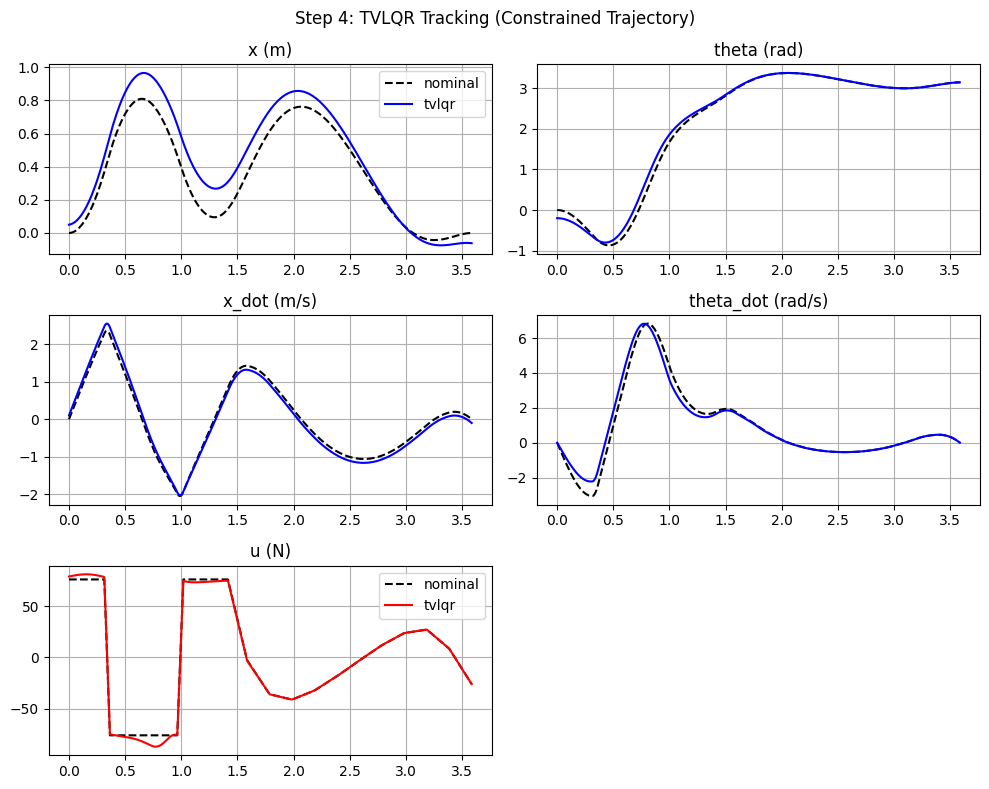

In [4]:
# 画对比曲线
def plot_tracking_results(xtraj, utraj, state_log, input_log):
    ts = state_log.sample_times()
    x_nom = xtraj.vector_values(ts)
    u_nom = utraj.vector_values(ts)
    x_act = state_log.data()
    u_act = input_log.data()

    fig, axes = plt.subplots(3, 2, figsize=(10, 8))
    axes = axes.flatten()
    labels = ["x (m)", "theta (rad)", "x_dot (m/s)", "theta_dot (rad/s)"]
    for i in range(4):
        axes[i].plot(ts, x_nom[i, :], "k--", label="nominal")
        axes[i].plot(ts, x_act[i, :], "b-", label="tvlqr")
        axes[i].set_title(labels[i])
        axes[i].grid(True)
        if i == 0:
            axes[i].legend()
    axes[4].plot(ts, u_nom[0, :], "k--", label="nominal")
    axes[4].plot(ts, u_act[0, :], "r-", label="tvlqr")
    axes[4].set_title("u (N)")
    axes[4].grid(True)
    axes[4].legend()
    axes[5].axis("off")
    plt.suptitle("Step 4: TVLQR Tracking (Constrained Trajectory)")
    plt.tight_layout()
    plt.show()

plot_tracking_results(xtraj, utraj, state_log, input_log)